In [1]:
!pip install curl_cffi yfinance matplotlib pandas

Fetching data for RELIANCE.NS...


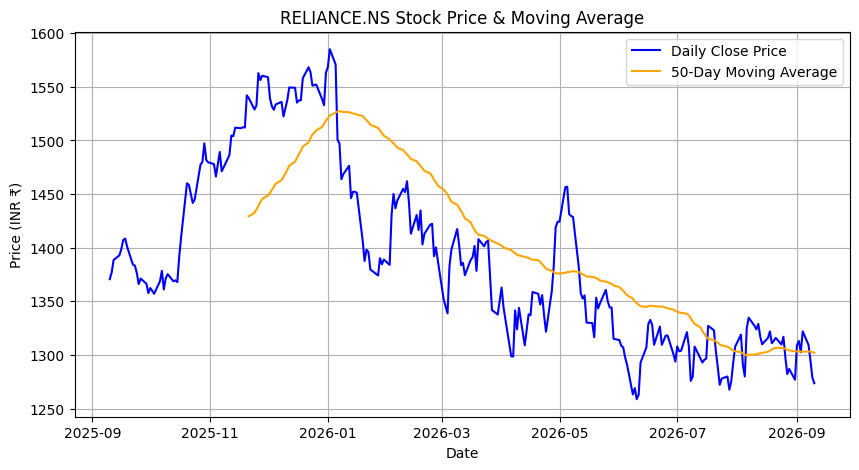

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from curl_cffi import requests

# Create a session that pretends to be a normal Chrome browser
session = requests.Session(impersonate="chrome")

# Define stock ticker (Add .NS for Indian stocks, e.g., RELIANCE.NS, HDFCBANK.NS)
ticker = "RELIANCE.NS"

print(f"Fetching data for {ticker}...")

# Fetch stock data using the browser session
stock = yf.Ticker(ticker, session=session)
stock_data = stock.history(period="1y")

# Check if data was successfully downloaded
if stock_data.empty:
    print(
        "Data fetch still blocked by campus network. Switch to phone hotspot and re-run."
    )
else:
    # Calculate 50-day moving average
    stock_data["MA50"] = stock_data["Close"].rolling(window=50).mean()

    # Plot the chart
    plt.figure(figsize=(10, 5))
    plt.plot(stock_data["Close"], label="Daily Close Price", color="blue")
    plt.plot(stock_data["MA50"], label="50-Day Moving Average", color="orange")
    plt.title(f"{ticker} Stock Price & Moving Average")
    plt.xlabel("Date")
    plt.ylabel("Price (INR ₹)")
    plt.legend()
    plt.grid(True)
    plt.show()

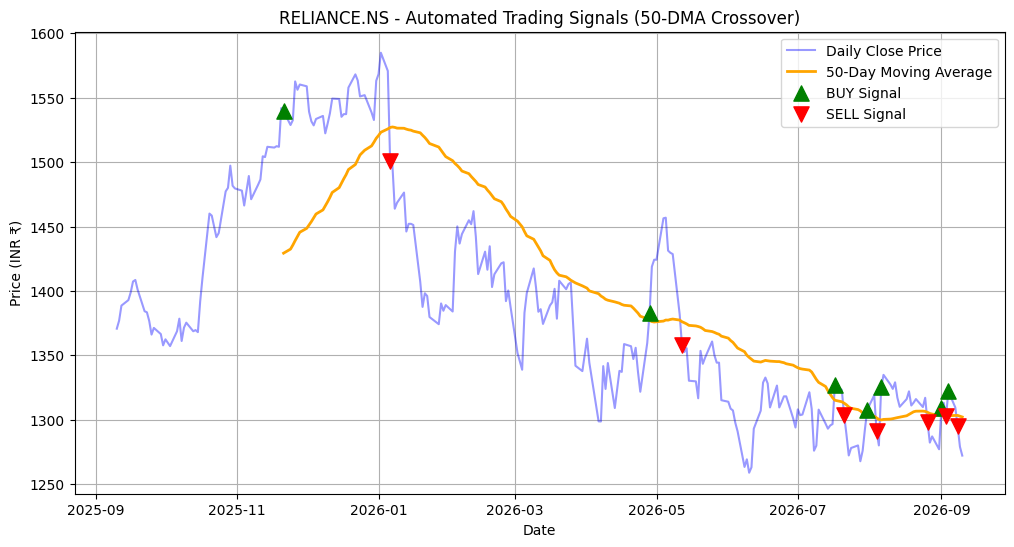

--- LATEST STRATEGY ALERTS ---
[2026-08-26] SELL Signal @ ₹1298.00 (MA50: ₹1305.72)
[2026-09-01] BUY Signal @ ₹1309.00 (MA50: ₹1303.35)
[2026-09-03] SELL Signal @ ₹1302.50 (MA50: ₹1303.03)
[2026-09-04] BUY Signal @ ₹1322.00 (MA50: ₹1303.11)
[2026-09-08] SELL Signal @ ₹1294.90 (MA50: ₹1303.30)


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from curl_cffi import requests

# 1. Fetch Data with Browser Session
session = requests.Session(impersonate="chrome")
ticker = "RELIANCE.NS"
stock = yf.Ticker(ticker, session=session)
df = stock.history(period="1y")

# 2. Calculate Indicators
df["MA50"] = df["Close"].rolling(window=50).mean()

# 3. Create Signals
# Signal = 1 when Close Price > 50 DMA, Signal = 0 otherwise
df["Signal"] = np.where(df["Close"] > df["MA50"], 1, 0)

# Position = 1 (BUY Signal), Position = -1 (SELL Signal)
df["Position"] = df["Signal"].diff()

# Extract exact dates where Buy/Sell signals occurred
buy_signals = df[df["Position"] == 1]
sell_signals = df[df["Position"] == -1]

# 4. Plot Chart with Crossover Markers
plt.figure(figsize=(12, 6))
plt.plot(df["Close"], label="Daily Close Price", color="blue", alpha=0.4)
plt.plot(df["MA50"], label="50-Day Moving Average", color="orange", linewidth=2)

# Plot Green Up Triangles for BUY
plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    marker="^",
    color="green",
    s=120,
    label="BUY Signal",
    zorder=5,
)

# Plot Red Down Triangles for SELL
plt.scatter(
    sell_signals.index,
    sell_signals["Close"],
    marker="v",
    color="red",
    s=120,
    label="SELL Signal",
    zorder=5,
)

plt.title(f"{ticker} - Automated Trading Signals (50-DMA Crossover)")
plt.xlabel("Date")
plt.ylabel("Price (INR ₹)")
plt.legend()
plt.grid(True)
plt.show()

# 5. Print Recent Actionable Signals
print("--- LATEST STRATEGY ALERTS ---")
latest_signals = df[df["Position"].isin([1, -1])][
    ["Close", "MA50", "Position"]
].tail(5)
for index, row in latest_signals.iterrows():
    action = "BUY" if row["Position"] == 1 else "SELL"
    date_str = index.strftime("%Y-%m-%d")
    print(
        f"[{date_str}] {action} Signal @ ₹{row['Close']:.2f} (MA50: ₹{row['MA50']:.2f})"
    )

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
from curl_cffi import requests

# 1. Fetch historical data using the browser session
session = requests.Session(impersonate="chrome")
ticker = "RELIANCE.NS"
stock = yf.Ticker(ticker, session=session)
df = stock.history(period="1y")

# 2. Calculate Indicators & Position Signals
df["MA50"] = df["Close"].rolling(window=50).mean()

# Position: 1 when invested (Price > MA50), 0 when in cash (Price <= MA50)
df["Position"] = np.where(df["Close"] > df["MA50"], 1, 0)

# Shift position by 1 day so we trade at the open/close AFTER the signal triggers
df["Position"] = df["Position"].shift(1)

# 3. Calculate Daily Returns
df["Daily_Return"] = df["Close"].pct_change()

# Strategy Return = Daily Return * Position
df["Strategy_Return"] = df["Daily_Return"] * df["Position"]

# 4. Calculate Cumulative Performance (Growth of ₹100,000 investment)
initial_capital = 100000
df["Buy_Hold_Portfolio"] = initial_capital * (1 + df["Daily_Return"]).cumprod()
df["Strategy_Portfolio"] = (
    initial_capital * (1 + df["Strategy_Return"]).cumprod()
)

# Clean NaN values from the rolling window start
df_clean = df.dropna()

# 5. Calculate Final Metrics
final_buy_hold = df_clean["Buy_Hold_Portfolio"].iloc[-1]
final_strategy = df_clean["Strategy_Portfolio"].iloc[-1]

buy_hold_return = ((final_buy_hold - initial_capital) / initial_capital) * 100
strategy_return = ((final_strategy - initial_capital) / initial_capital) * 100

print("=" * 45)
print(f"BACKTEST RESULTS: {ticker} (1-Year Period)")
print("=" * 45)
print(f"Initial Capital      : ₹{initial_capital:,.2f}")
print(
    f"Buy & Hold Final     : ₹{final_buy_hold:,.2f} ({buy_hold_return:+.2f}%)"
)
print(
    f"50-DMA Strategy Final: ₹{final_strategy:,.2f} ({strategy_return:+.2f}%)"
)
print("-" * 45)
if strategy_return > buy_hold_return:
    print(
        f"RESULT: 50-DMA Strategy OUTPERFORMED Buy & Hold by {strategy_return - buy_hold_return:.2f}%!"
    )
else:
    print(
        f"RESULT: Buy & Hold OUTPERFORMED 50-DMA Strategy by {buy_hold_return - strategy_return:.2f}%!"
    )
print("=" * 45)

BACKTEST RESULTS: RELIANCE.NS (1-Year Period)
Initial Capital      : ₹100,000.00
Buy & Hold Final     : ₹92,845.60 (-7.15%)
50-DMA Strategy Final: ₹88,622.86 (-11.38%)
---------------------------------------------
RESULT: Buy & Hold OUTPERFORMED 50-DMA Strategy by 4.22%!


In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
from curl_cffi import requests

# 1. Fetch 3 years of data (200-DMA needs more price history to calculate)
session = requests.Session(impersonate="chrome")
ticker = "RELIANCE.NS"
stock = yf.Ticker(ticker, session=session)
df = stock.history(period="3y")

# 2. Calculate Fast (50) and Slow (200) Moving Averages
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

# 3. Position Logic: Invested (1) when 50-DMA > 200-DMA, Cash (0) otherwise
df["Position"] = np.where(df["MA50"] > df["MA200"], 1, 0)
df["Position"] = df["Position"].shift(1)  # Shift 1 day to prevent lookahead bias

# 4. Calculate Returns
df["Daily_Return"] = df["Close"].pct_change()
df["Strategy_Return"] = df["Daily_Return"] * df["Position"]

# 5. Cumulative Portfolio Value (₹100,000 starting capital)
initial_capital = 100000
df_clean = df.dropna().copy()

df_clean["Buy_Hold"] = initial_capital * (1 + df_clean["Daily_Return"]).cumprod()
df_clean["Dual_MA_Strategy"] = (
    initial_capital * (1 + df_clean["Strategy_Return"]).cumprod()
)

# 6. Final Performance Breakdown
final_bh = df_clean["Buy_Hold"].iloc[-1]
final_strat = df_clean["Dual_MA_Strategy"].iloc[-1]

ret_bh = ((final_bh - initial_capital) / initial_capital) * 100
ret_strat = ((final_strat - initial_capital) / initial_capital) * 100

print("=" * 50)
print(f"3-YEAR DUAL CROSSOVER BACKTEST: {ticker}")
print("=" * 50)
print(f"Buy & Hold Final Return : {ret_bh:+.2f}% (₹{final_bh:,.2f})")
print(f"Dual MA Strategy Return : {ret_strat:+.2f}% (₹{final_strat:,.2f})")
print("-" * 50)

if ret_strat > ret_bh:
    print(
        f"SUCCESS: Dual Crossover OUTPERFORMED Buy & Hold by {ret_strat - ret_bh:.2f}%!"
    )
else:
    print(f"Buy & Hold outperformed Dual Crossover by {ret_bh - ret_strat:.2f}%")
print("=" * 50)

3-YEAR DUAL CROSSOVER BACKTEST: RELIANCE.NS
Buy & Hold Final Return : -18.88% (₹81,124.01)
Dual MA Strategy Return : -15.40% (₹84,597.95)
--------------------------------------------------
SUCCESS: Dual Crossover OUTPERFORMED Buy & Hold by 3.47%!


"Quantitative Analysis: Single vs. Dual Moving Average Backtest on Reliance Industries"